<a href="https://colab.research.google.com/github/vidhya2432/Gen-AI/blob/main/Intership_Task_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 1: Fake News Detection using Python

Build a Machine Learning model that:




*   Takes news text as input
*   Classifies it as Fake or Real



*   Promotes information accuracy



















In [ ]:
import pandas as pd
import numpy as np
import string
import matplotlib.pyplot as plt
import seaborn as sns

**Pandas** → load and manipulate dataset

**Numpy** → numerical operations

**String** → remove punctuation

**Matplotlib & seaborn** → visualization

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**train_test_split** → divide data into training & testing

**TfidfVectorizer** → convert text into numbers

**accuracy_score** → calculate performance

**confusion_matrix** → evaluate prediction quality

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

We compare 3 ML models:



*  Logistic Regression





*   Naive Bayes
*   Random Forest










In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

To remove common words like:

1. the

2. is

3. in

4. and

These words don’t help detect fake news.

In [ ]:
fake = pd.read_csv("/content/Fake.csv.zip")
real = pd.read_csv("/content/True.csv.zip")

fake["label"] = 0   # Fake
real["label"] = 1   # Real

data = pd.concat([fake, real], axis=0)
data = data.sample(frac=1).reset_index(drop=True)

Loads two files:

1. Fake news articles

2. Real news articles

In [ ]:
# -------------------------------
# Text Preprocessing
# -------------------------------

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()  # Lowercase
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    words = text.split()
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    return " ".join(words)

data["clean_text"] = data["text"].apply(clean_text)

X = data["clean_text"]
y = data["label"]

###Text Preprocessing:



*   Load English stopwords.

*   Convert everything to lowercase.

    Example:
      "FAKE News" → "fake news"
*   Removes punctuation.

    Example:
      "fake news!!!" → "fake news"


*   Split sentence into words.

Now dataset has cleaned text.



In [ ]:
# -------------------------------
# Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
 )

80% → Training

20% → Testing

We train on 80%

We test on unseen 20%

In [ ]:
# -------------------------------
# TF-IDF Vectorization
# -------------------------------
vectorizer = TfidfVectorizer(max_df=0.7)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

TF = Term Frequency

IDF = Inverse Document Frequency

It converts text into numbers based on word importance.

Important words → higher weight

Common words → lower weight

In [ ]:
# -------------------------------
# Model 1: Logistic Regression
# -------------------------------
lr = LogisticRegression()
lr.fit(X_train_vec, y_train)
lr_pred = lr.predict(X_test_vec)
lr_acc = accuracy_score(y_test, lr_pred)

In [ ]:
# -------------------------------
# Model 2: Naive Bayes
# -------------------------------
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
nb_pred = nb.predict(X_test_vec)
nb_acc = accuracy_score(y_test, nb_pred)

In [ ]:
# -------------------------------
# Model 3: Random Forest
# -------------------------------
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_vec, y_train)
rf_pred = rf.predict(X_test_vec)
rf_acc = accuracy_score(y_test, rf_pred)

In [ ]:
#Result

print("Logistic Regression Accuracy:", lr_acc)
print("Naive Bayes Accuracy:", nb_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.9891982182628062
Naive Bayes Accuracy: 0.9516703786191537
Random Forest Accuracy: 0.9937639198218263


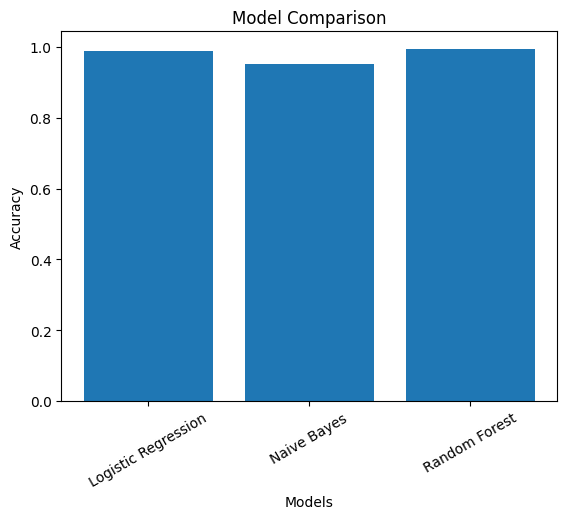

In [ ]:
# -------------------------------
# Accuracy Comparison Plot
# -------------------------------
models = ["Logistic Regression", "Naive Bayes", "Random Forest"]
accuracies = [lr_acc, nb_acc, rf_acc]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=30)
plt.show()

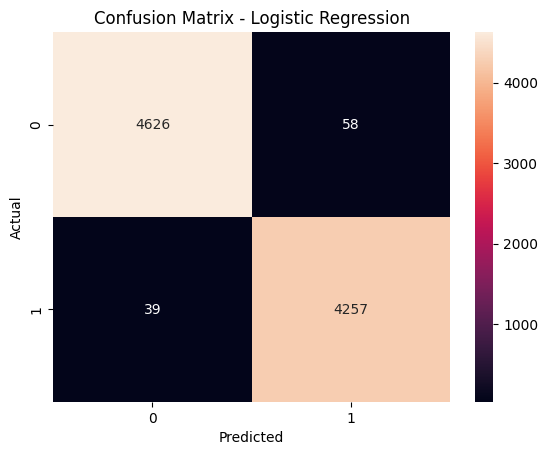

In [ ]:
# -------------------------------
# Confusion Matrix (Best Model)
# -------------------------------
cm = confusion_matrix(y_test, lr_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()